<a href="https://colab.research.google.com/github/tanishqsayil-lab/MLEL--Experiment/blob/main/assign7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

In [12]:
iris = load_iris()
wine = load_wine()

print("Iris Records:", iris.data.shape[0])
print("Iris Classes:", len(iris.target_names))
print("Iris Features:", iris.feature_names)

print()

print("Wine Records:", wine.data.shape[0])
print("Wine Classes:", len(wine.target_names))
print("Wine Features:", wine.feature_names)

Iris Records: 150
Iris Classes: 3
Iris Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Wine Records: 178
Wine Classes: 3
Wine Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (120, 4)
Test Shape: (30, 4)


In [14]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

pred1 = svm_linear.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, pred1))
print("Support Vectors:")
print(svm_linear.n_support_)

Linear SVM Accuracy: 1.0
Support Vectors:
[ 3 11 11]


In [15]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

pred2 = svm_rbf.predict(X_test)

print("RBF SVM Accuracy:", accuracy_score(y_test, pred2))

RBF SVM Accuracy: 1.0


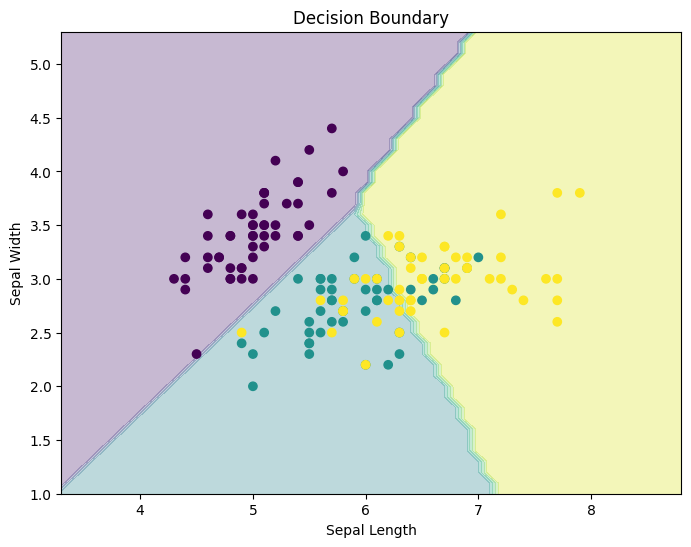

In [16]:
X = iris.data[:, :2]
y = iris.target

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVC(kernel='linear')
model.fit(X_train2, y_train2)

x1, x2 = np.meshgrid(
    np.arange(X[:,0].min()-1, X[:,0].max()+1, 0.1),
    np.arange(X[:,1].min()-1, X[:,1].max()+1, 0.1)
)

Z = model.predict(np.array([x1.ravel(), x2.ravel()]).T)
Z = Z.reshape(x1.shape)

plt.figure(figsize=(8,6))
plt.contourf(x1, x2, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Decision Boundary")
plt.show()

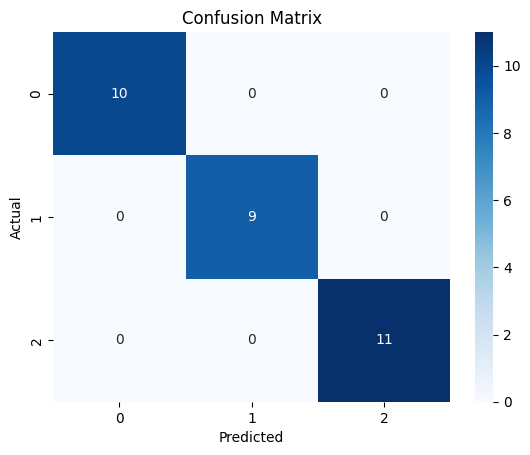

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [17]:
cm = confusion_matrix(y_test, pred2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, pred2))

In [18]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

pred3 = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred3))

Logistic Regression Accuracy: 1.0


In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred4 = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred4))

KNN Accuracy: 1.0


In [20]:
table = pd.DataFrame({
    "Model":["Logistic Regression","SVM Linear","SVM RBF","KNN"],
    "Accuracy":[
        accuracy_score(y_test,pred3),
        accuracy_score(y_test,pred1),
        accuracy_score(y_test,pred2),
        accuracy_score(y_test,pred4)
    ]
})

print(table)

print("\nSVM works well for clear class separation.")
print("Do not use SVM for very large datasets.")
print("Kernels help classify non-linear data.")

                 Model  Accuracy
0  Logistic Regression       1.0
1           SVM Linear       1.0
2              SVM RBF       1.0
3                  KNN       1.0

SVM works well for clear class separation.
Do not use SVM for very large datasets.
Kernels help classify non-linear data.
